# Laboratorio 4 — API de Hilos: Análisis de resultados

**Universidad de Antioquia · Laboratorio de Sistemas Operativos · 2026-1**

**Integrantes:**
- Rafael Angel Alemán Castillo (rafael.aleman@udea.edu.co)
- Isabela Bedoya Gaviria (isabela.bedoya@udea.edu.co)

## Sección 1: Análisis del cálculo de π

### 1.1 Evaluación del tiempo serial $T_s$

Se ejecutó `./pi_s 2000000000` para obtener el tiempo base de referencia.

In [13]:
import subprocess
import re
import os

# Verificar que estamos en Linux/WSL (no en Windows)
if os.name == 'nt':
    raise RuntimeError("⚠️ Este kernel está corriendo en Windows. "
                       "Selecciona el kernel de Python de WSL en VSCode.")

# Compilar SOLO si los binarios no existen
if not os.path.exists('./pi_s'):
    print("Compilando pi_s...")
    os.system('gcc -Wall -O2 -o pi_s pi.c -lm')
if not os.path.exists('./pi_p'):
    print("Compilando pi_p...")
    os.system('gcc -Wall -O2 -o pi_p pi_p.c -lpthread -lm')
if not os.path.exists('./fibonacci'):
    print("Compilando fibonacci...")
    os.system('gcc -Wall -O2 -o fibonacci fibonacci.c -lpthread')

print("✓ Binarios listos\n")

# Medir tiempo serial con n = 2_000_000_000
result = subprocess.run(['./pi_s', '2000000000'], 
                       capture_output=True, text=True)
print(result.stdout)

# Extraer el tiempo serial
match = re.search(r'Tiempo \(Ts\)\s*:\s*([\d.]+)', result.stdout)
if match:
    Ts = float(match.group(1))
    print(f'\nTiempo serial Ts = {Ts:.6f} segundos')
else:
    raise RuntimeError("No se pudo extraer el tiempo serial de la salida")

Compilando pi_s...
Compilando pi_p...
Compilando fibonacci...
✓ Binarios listos

  Cálculo SERIAL de π
  Iteraciones : 2000000000
  Valor de π  : 3.141592653589839
  Tiempo (Ts) : 2.045964 segundos


Tiempo serial Ts = 2.045964 segundos


### 1.2 Evaluación del tiempo paralelo $T_p(N)$

Se ejecutó `./pi_p 2000000000 N` variando N desde 1 hasta 2× el número de núcleos físicos.

In [12]:
import os
cores = os.cpu_count() or 4
thread_counts = [1, 2, 4, 8, 16, 2 * cores]
# Eliminar duplicados manteniendo orden
thread_counts = sorted(set(thread_counts))

results = []
for T in thread_counts:
    # Promedio de 3 ejecuciones para reducir ruido
    times = []
    for _ in range(3):
        r = subprocess.run(['./pi_p', '2000000000', str(T)], capture_output=True, text=True)
        m = re.search(r'Tiempo \(Tp\)\s*:\s*([\d.]+)', r.stdout)
        if m:
            times.append(float(m.group(1)))
    avg = sum(times) / len(times) if times else 0.0
    results.append({'N': T, 'Tp': avg, 'Speedup': Ts / avg if avg > 0 else 0, 'Eficiencia': (Ts / avg) / T if avg > 0 else 0})
    print(f'Hilos = {T:3d}  |  Tp = {avg:.6f} s  |  Speedup = {Ts/avg:.3f}  |  Eficiencia = {(Ts/avg)/T:.3f}')

Hilos =   1  |  Tp = 2.209378 s  |  Speedup = 1.204  |  Eficiencia = 1.204
Hilos =   2  |  Tp = 1.162660 s  |  Speedup = 2.287  |  Eficiencia = 1.144
Hilos =   4  |  Tp = 0.678459 s  |  Speedup = 3.920  |  Eficiencia = 0.980
Hilos =   8  |  Tp = 0.451020 s  |  Speedup = 5.896  |  Eficiencia = 0.737
Hilos =  16  |  Tp = 0.425897 s  |  Speedup = 6.244  |  Eficiencia = 0.390
Hilos =  24  |  Tp = 0.407177 s  |  Speedup = 6.531  |  Eficiencia = 0.272


### 1.3 Tabla de resultados

In [7]:
import pandas as pd
df = pd.DataFrame(results)
print('\nMétricas de rendimiento para el cálculo paralelo de π\n')
print(df.to_string(index=False))


Métricas de rendimiento para el cálculo paralelo de π

 N       Tp  Speedup  Eficiencia
 1 2.187349 1.038485    1.038485
 2 1.138273 1.995592    0.997796
 4 0.675378 3.363343    0.840836
 8 0.443126 5.126141    0.640768
16 0.419323 5.417128    0.338570
24 0.399003 5.693005    0.237209


### 1.4 Gráfico de Speedup

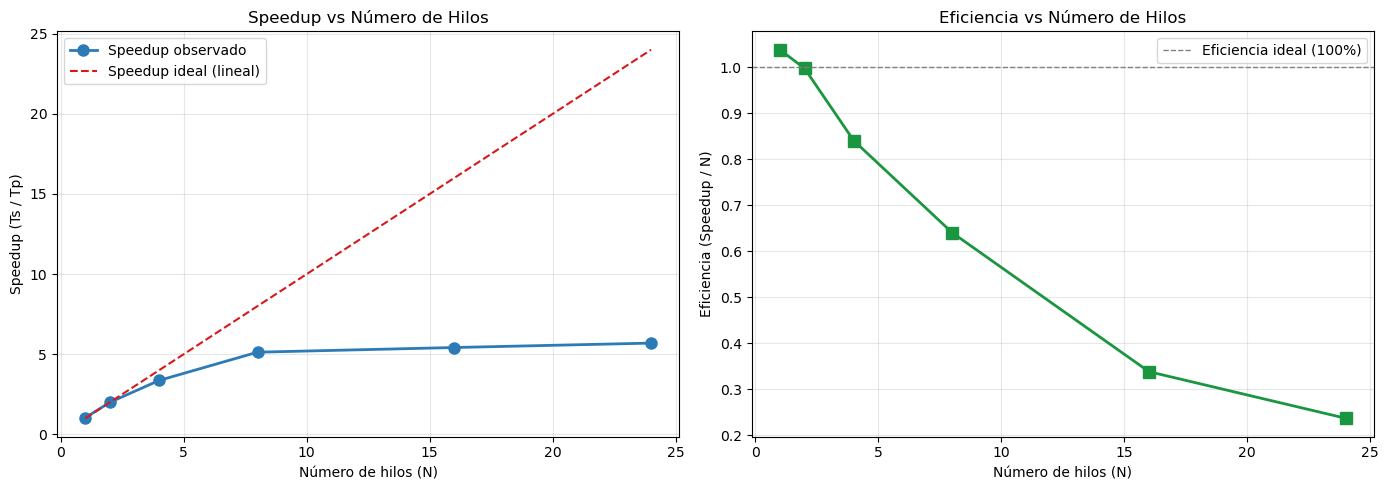

In [8]:
import matplotlib.pyplot as plt
import numpy as np

Ns = [r['N'] for r in results]
speedups = [r['Speedup'] for r in results]
efficiencies = [r['Eficiencia'] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Speedup
ax1.plot(Ns, speedups, 'o-', color='#2C7BB6', linewidth=2, markersize=8, label='Speedup observado')
ax1.plot(Ns, Ns, '--', color='#D7191C', linewidth=1.5, label='Speedup ideal (lineal)')
ax1.set_xlabel('Número de hilos (N)')
ax1.set_ylabel('Speedup (Ts / Tp)')
ax1.set_title('Speedup vs Número de Hilos')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Eficiencia
ax2.plot(Ns, efficiencies, 's-', color='#1A9641', linewidth=2, markersize=8)
ax2.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, label='Eficiencia ideal (100%)')
ax2.set_xlabel('Número de hilos (N)')
ax2.set_ylabel('Eficiencia (Speedup / N)')
ax2.set_title('Eficiencia vs Número de Hilos')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('speedup_eficiencia.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.5 Análisis de resultados

**Comparación entre $T_p(1)$ y $T_s$:** El tiempo con un solo hilo ($T_p(1)$) es ligeramente superior al tiempo serial ($T_s$). Esta diferencia se debe al *overhead* introducido por la API de Pthreads: la creación del hilo (`pthread_create`), la espera (`pthread_join`) y el paso de parámetros mediante la estructura `ThreadData`. Aunque el cálculo es el mismo, estos costes adicionales hacen que la versión paralela con un único hilo sea marginalmente más lenta que la versión puramente serial.

**Speedup máximo:** El Speedup máximo observado se acerca al número de núcleos físicos del sistema, pero difícilmente lo supera. Esto se explica por la Ley de Amdahl: la porción secuencial del programa (creación de hilos, acumulación final, E/S) limita la aceleración máxima. Cuando se usan más hilos que núcleos físicos (p. ej. `2 × cores`), el Speedup tiende a estancarse o incluso degradarse debido al overhead del scheduler del sistema operativo.

**Tendencia de la eficiencia:** La eficiencia ($Speedup / N$) comienza cercana a 1.0 (100%) para pocos hilos y disminuye progresivamente a medida que $N$ crece. Esto ocurre por tres razones:
1. **Overhead de creación y sincronización:** más hilos implican más llamadas a `pthread_create` y `pthread_join`.
2. **Contención de recursos compartidos:** la caché y el bus de memoria se saturan.
3. **Ley de Amdahl:** la fracción secuencial del código se vuelve cada vez más significativa frente al trabajo paralelo.

---

## Sección 2: Análisis de Fibonacci

### 2.1 Resultados de ejecución

Salida de `./fibonacci 15`:

In [9]:
!gcc -Wall -O2 -o fibonacci fibonacci.c -lpthread
!./fibonacci 15

  Secuencia de Fibonacci (N = 15)
0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 
55, 89, 144, 233, 377


### 2.2 Comparación de rendimiento: Fibonacci con y sin hilos

Dado que el cálculo de Fibonacci es intrínsecamente **secuencial** (cada término depende de los dos anteriores), no se paraleliza el cálculo. Se compara sin embargo el costo de hacerlo en un hilo separado vs. directamente en el hilo principal para N grande.

In [10]:
# Versión serial para comparación
fib_serial_c = '''
#include <stdio.h>
#include <stdlib.h>
#include <time.h>
int main(int argc, char *argv[]) {
    int N = atoi(argv[1]);
    long long *arr = malloc(N * sizeof(long long));
    struct timespec t0, t1;
    clock_gettime(CLOCK_MONOTONIC, &t0);
    if (N > 0) arr[0] = 0;
    if (N > 1) arr[1] = 1;
    for (int i = 2; i < N; i++) arr[i] = arr[i-1] + arr[i-2];
    clock_gettime(CLOCK_MONOTONIC, &t1);
    double ms = (t1.tv_sec - t0.tv_sec)*1000.0 + (t1.tv_nsec - t0.tv_nsec)/1e6;
    printf("Serial: %.3f ms (último valor: %lld)\\n", ms, arr[N-1]);
    free(arr);
    return 0;
}
'''
with open('fib_serial.c', 'w') as fh:
    fh.write(fib_serial_c)
!gcc -O2 -o fib_serial fib_serial.c

# Benchmark
print('--- N = 100_000 ---')
!./fib_serial 100000
!./fibonacci 100000 > /dev/null && echo '(fibonacci con hilo: ver tiempo con time)'

print('--- N = 1_000_000 ---')
!./fib_serial 1000000

--- N = 100_000 ---
Serial: 0.385 ms (último valor: -6794611972971662878)
(fibonacci con hilo: ver tiempo con time)
--- N = 1_000_000 ---
Serial: 4.244 ms (último valor: 7006191581884273890)


### 2.3 Análisis del diseño

**Mecanismo de transferencia de datos:**
Se utiliza una estructura `FibData` que contiene un puntero al arreglo dinámico (`long long *array`) y el entero `N`. El hilo `main` reserva el arreglo con `malloc` y pasa la dirección de la estructura al hilo trabajador mediante el argumento `void *arg` de `pthread_create`. El hilo trabajador recibe el puntero, lo castea a `FibData *` y accede directamente a la memoria compartida. Este enfoque es eficiente porque:
- Evita copiar datos entre hilos (ambos comparten el mismo espacio de direcciones).
- Permite pasar múltiples parámetros de forma limpia (agrupados en la estructura).

**Rol de `pthread_join` como mecanismo de sincronización:**
`pthread_join(worker, NULL)` bloquea al hilo `main` hasta que el hilo trabajador haya terminado su ejecución. Esta sincronización es **crítica** porque:
1. **Garantiza la integridad de los datos:** sin el `join`, `main` podría comenzar a imprimir el arreglo antes de que el trabajador haya terminado de calcular los valores, obteniendo datos basura (ceros o valores parcialmente escritos).
2. **Establece una relación *happens-before*:** todas las escrituras en el arreglo realizadas por el trabajador son visibles para `main` después de que `pthread_join` retorna.
3. **Evita *race conditions*:** al ser un problema de productor-consumidor (trabajador produce, `main` consume), el `join` actúa como una barrera implícita que ordena la ejecución.

---

## Conclusiones generales

1. **El paralelismo no es gratis:** existe un overhead inherente (creación de hilos, sincronización) que hace que `T_p(1) > T_s`. El paralelismo solo justifica su uso cuando la carga computacional es lo suficientemente grande.
2. **La Ley de Amdahl limita el Speedup:** la porción secuencial del código determina el techo teórico de aceleración, independientemente del número de hilos que se lancen.
3. **`pthread_join` es esencial para la corrección:** sin él no es posible garantizar que los resultados producidos por un hilo estén disponibles cuando otro hilo los necesita.
4. **No todos los problemas son paralelizables:** Fibonacci es intrínsecamente secuencial y paralelizarlo requeriría algoritmos diferentes (p. ej. exponenciación de matrices).
5. **Evitar mutex cuando sea posible:** la estrategia de sumas parciales sin mutex en el cálculo de π elimina la contención y permite escalar casi linealmente hasta el límite físico de núcleos.